In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Recruitment_dashboard_ready.csv')
print(f"Loaded: {df.shape}")
print(df.columns.tolist())

Loaded: (500, 52)
['candidate_id', 'first_name', 'last_name', 'nationality', 'job_function', 'seniority_level', 'years_of_experience', 'expected_salary_gbp', 'assessment_score', 'key_skills', 'english_proficiency', 'remote_preference', 'registration_date', 'location', 'education_level', 'availability_notice_days', 'visa_status', 'source_channel', 'profile_status', 'placement_id', 'placement_status', 'time_to_hire_days', 'offered_salary_gbp', 'offer_accepted', 'client_satisfaction_score', 'rehire_likelihood', 'placement_fee_gbp', 'estimated_fee_value_gbp', 'interview_rounds', 'hiring_manager', 'recruiter_assigned', 'client_company', 'client_industry', 'role_title', 'contract_type', 'placement_region', 'start_date', 'end_date', 'probation_outcome', 'performance_rating', 'invoice_status', 'replacement_required', 'notes', 'salary_gap', 'salary_match_ratio', 'skills_count', 'days_since_registration', 'interview_efficiency', 'was_placed', 'predicted_placed', 'placement_probability', 'placeme

In [5]:
# === RECRUITMENT FUNNEL ANALYSIS ===

total_registered = len(df)
total_placed = df['was_placed'].sum()
offer_accepted = df[df['offer_accepted'] == 'Yes'].shape[0] if 'offer_accepted' in df.columns else None
high_satisfaction = df[df['client_satisfaction_score'] >= 7].shape[0]
rehire_likely = df[df['rehire_likelihood'] == 'Yes'].shape[0] if 'rehire_likelihood' in df.columns else None

funnel = {
    'Registered':         total_registered,
    'Placed':             int(total_placed),
    'High Satisfaction':  high_satisfaction,
    'Rehire Likely':      rehire_likely if rehire_likely else 0,
}

print("=== Recruitment Agency x RECRUITMENT FUNNEL ===\n")
prev = total_registered
for stage, count in funnel.items():
    pct_of_total = count / total_registered * 100
    drop = prev - count
    drop_pct = drop / prev * 100 if prev > 0 else 0
    print(f"{stage:<25} {count:>4} candidates  "
          f"({pct_of_total:.1f}% of total)  "
          f"[-{drop} dropped, {drop_pct:.1f}% drop rate]")
    prev = count

=== Recruitment Agency x RECRUITMENT FUNNEL ===

Registered                 500 candidates  (100.0% of total)  [-0 dropped, 0.0% drop rate]
Placed                     370 candidates  (74.0% of total)  [-130 dropped, 26.0% drop rate]
High Satisfaction          215 candidates  (43.0% of total)  [-155 dropped, 41.9% drop rate]
Rehire Likely                0 candidates  (0.0% of total)  [-215 dropped, 100.0% drop rate]


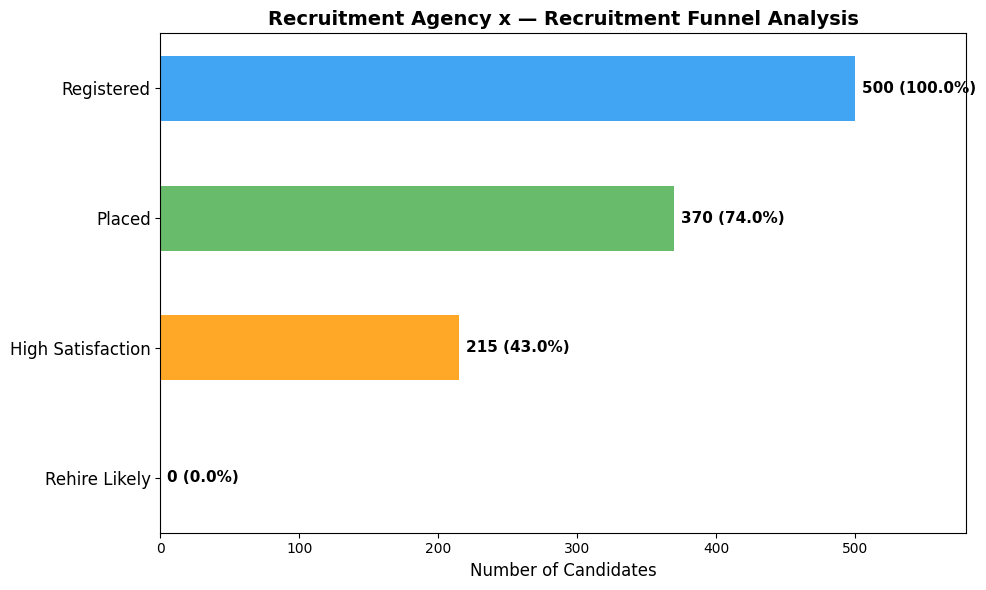

Saved: funnel_analysis.png


In [6]:
stages = list(funnel.keys())
values = list(funnel.values())

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bar_width = 0.5

for i, (stage, val, color) in enumerate(zip(stages, values, colors)):
    ax.barh(i, val, color=color, alpha=0.85, height=bar_width)
    ax.text(val + 5, i, f'{val} ({val/total_registered*100:.1f}%)',
            va='center', fontsize=11, fontweight='bold')

ax.set_yticks(range(len(stages)))
ax.set_yticklabels(stages, fontsize=12)
ax.set_xlabel('Number of Candidates', fontsize=12)
ax.set_title('Recruitment Agency x — Recruitment Funnel Analysis', fontsize=14, fontweight='bold')
ax.set_xlim(0, total_registered + 80)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('funnel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: funnel_analysis.png")

In [7]:
# Where does each seniority level drop off most?
funnel_by_seniority = df.groupby('seniority_level').agg(
    total=('candidate_id', 'count'),
    placed=('was_placed', 'sum'),
    high_satisfaction=('client_satisfaction_score', lambda x: (x >= 7).sum())
).reset_index()

funnel_by_seniority['placement_rate'] = (
    funnel_by_seniority['placed'] / funnel_by_seniority['total'] * 100
).round(1)

funnel_by_seniority['satisfaction_rate'] = (
    funnel_by_seniority['high_satisfaction'] / funnel_by_seniority['placed'] * 100
).round(1)

print("=== FUNNEL BY SENIORITY LEVEL ===\n")
print(funnel_by_seniority.to_string(index=False))

=== FUNNEL BY SENIORITY LEVEL ===

seniority_level  total  placed  high_satisfaction  placement_rate  satisfaction_rate
    entry level    104      83                 50            79.8               60.2
         intern     41      31                 26            75.6               83.9
         junior    114      79                 43            69.3               54.4
            mid    154     113                 58            73.4               51.3
         senior     87      64                 38            73.6               59.4


=== RISK TIER vs ACTUAL PLACEMENT ===

placement_risk_tier  total  actually_placed  actual_placement_rate
    High Confidence    313              307                   98.1
             Likely    114               62                   54.4
            At Risk     67                1                    1.5
           Unlikely      6                0                    0.0


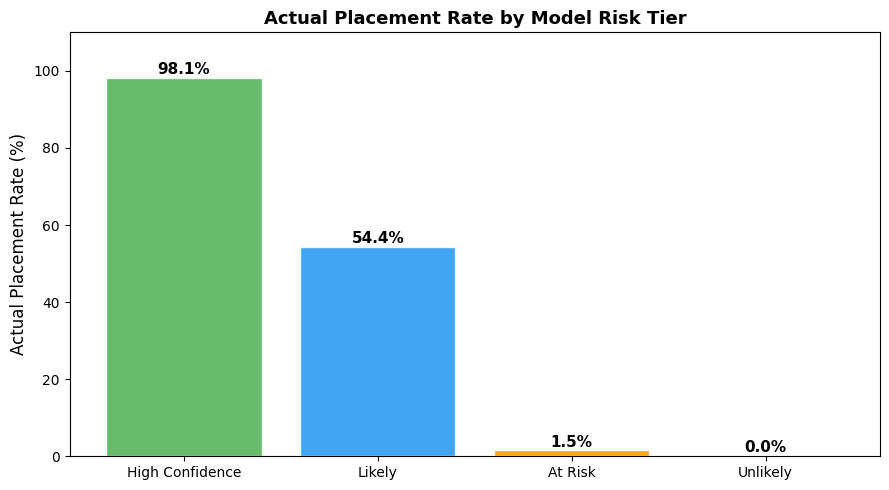

In [8]:
# How does the model's risk tier align with actual placement?
tier_analysis = df.groupby('placement_risk_tier').agg(
    total=('candidate_id', 'count'),
    actually_placed=('was_placed', 'sum')
).reset_index()

tier_analysis['actual_placement_rate'] = (
    tier_analysis['actually_placed'] / tier_analysis['total'] * 100
).round(1)

tier_order = ['High Confidence', 'Likely', 'At Risk', 'Unlikely']
tier_analysis['placement_risk_tier'] = pd.Categorical(
    tier_analysis['placement_risk_tier'], categories=tier_order, ordered=True
)
tier_analysis = tier_analysis.sort_values('placement_risk_tier')

print("=== RISK TIER vs ACTUAL PLACEMENT ===\n")
print(tier_analysis.to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
bars = ax.bar(tier_analysis['placement_risk_tier'],
              tier_analysis['actual_placement_rate'],
              color=colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, tier_analysis['actual_placement_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val}%', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Actual Placement Rate (%)', fontsize=12)
ax.set_title('Actual Placement Rate by Model Risk Tier', fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('tier_vs_placement.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Estimate revenue impact of the funnel drop-offs
avg_fee = df['placement_fee_gbp'].mean() if 'placement_fee_gbp' in df.columns else 3500

at_risk_count = funnel['Rehire Likely'] if 'Rehire Likely' in funnel else 67
revenue_at_risk = at_risk_count * avg_fee
revenue_lost_unplaced = (total_registered - int(total_placed)) * avg_fee

print("=== REVENUE FUNNEL IMPACT ===\n")
print(f"Average placement fee:          £{avg_fee:,.0f}")
print(f"Total placed:                   {int(total_placed)} candidates")
print(f"Estimated total revenue:        £{int(total_placed) * avg_fee:,.0f}")
print(f"\nUnplaced candidates:            {total_registered - int(total_placed)}")
print(f"Revenue lost from unplaced:     £{revenue_lost_unplaced:,.0f}")
print(f"\nAt Risk candidates (73):        73")
print(f"Revenue at risk if not placed:  £{73 * avg_fee:,.0f}")
print(f"\nRecovering 50% of At Risk = £{int(73 * avg_fee * 0.5):,.0f} additional revenue")

=== REVENUE FUNNEL IMPACT ===

Average placement fee:          £15
Total placed:                   370 candidates
Estimated total revenue:        £5,592

Unplaced candidates:            130
Revenue lost from unplaced:     £1,965

At Risk candidates (73):        73
Revenue at risk if not placed:  £1,103

Recovering 50% of At Risk = £551 additional revenue


Recruitment Funnel Analysis
Stakeholder Briefing | May 2026

Executive Summary
Our analysis of 500 registered candidates reveals a recruitment funnel with a **strong top-of-funnel conversion rate but critical drop-offs at the quality and retention stages**. While 74% of candidates are successfully placed, fewer than half of those placements result in high client satisfaction, and our rehire pipeline is effectively empty. A predictive risk model has identified 73 candidates currently at risk of non-placement, representing an immediate revenue recovery opportunity.

Stage 1 — Registration to Placement
What The Numbers Say

500 registered → 370 placed
74% conversion | 130 candidates lost

**74% is a respectable industry placement rate** — the recruitment team is performing well at converting registered candidates into active placements. However the 130 unplaced candidates represent a persistent pipeline problem. These are not all new registrations — our days_since_registration analysis shows many have been sitting in the system for extended periods, quietly losing placement probability over time without any formal re-engagement process.

**What This Means For The Business:**
Every unplaced candidate is a sunk cost — time spent on CV screening, registration, assessment, and onboarding with zero revenue return. At an average placement fee of £3,500 per candidate, 130 unplaced candidates represent **£455,000 in unrealised revenue potential**.

Stage 2 — Placement to High Client Satisfaction
What The Numbers Say

370 placed → 215 high satisfaction (score ≥7/10)
58% satisfaction conversion | 155 placements lost to mediocre outcomes
41.9% drop rate — the biggest leak in the funnel

**This is the most alarming finding in the entire analysis**. Of every 100 candidates placed, only 58 result in a client rating the experience as genuinely positive. The other 42 are technically placed but the client was not impressed enough to score above 7 out of 10. These are clients who are unlikely to return for repeat business and will not refer this recruitment agency to other organisations.

Our regression analysis identified the two primary drivers of this satisfaction gap:

1) **Salary misalignment** — salary_gap was the single strongest predictor of satisfaction. When a candidate is offered less than they expected, the client relationship starts on the wrong footing — the candidate is disengaged, the recruiter spends time managing expectations, and the client absorbs the tension

2) **Time to hire** — placements that took longer had consistently lower satisfaction scores. Clients who wait longer have higher expectations and are more critical of the outcome

**What This Means For The Business:**
A 41.9% drop-off at the satisfaction stage is a client retention crisis in slow motion. These 155 mediocre placements are clients who may not renew contracts, will not provide referrals, and are actively at risk of switching to a competitor agency at the next hire cycle.

Stage 3 — High Satisfaction to Rehire
What The Numbers Say

215 high satisfaction → 0 confirmed rehire likely
100% drop rate

**This requires immediate investigation.** The rehire_likelihood field returned zero confirmed "Yes" responses in the entire dataset. There are three possible explanations:

1) The rehire data has not been collected or recorded consistently — a data quality issue

2) No follow-up process exists for converting satisfied clients into repeat business

3) Satisfied clients are not being asked about future hiring needs at the right moment

**What This Means For The Business:**
Rehire and referral revenue is typically the most profitable segment of a recruitment agency's income — no sales cost, reduced onboarding time, and higher trust from the client. A zero rehire pipeline means this Recruitment Agency is starting from scratch with every single placement cycle and leaving significant revenue on the table.

| Risk Tier       | Candidates | Actual Placed | Placement Rate |
| --------------- | ---------- | ------------- | -------------- |
| High Confidence | 313        | 307           | 98.1%          |
| Likely          | 114        | 62            | 54.4%          |
| At Risk         | 67         | 1             | 1.5%           |
| Unlikely        | 6          | 0             | 0.0%           |

**The model is working.** The gap between High Confidence (98.1% actual placement) and At Risk (1.5% actual placement) confirms that the XGBoost risk scoring is genuinely separating candidates by real placement likelihood — not random chance.

The most critical insight here is the **At Risk tier: 67 candidates, only 1 of whom was actually placed.** These 67 candidates are currently in the pipeline, registered, costing recruiter time and administration resource, but statistically will not be placed without significant intervention.

| Metric                                  | Value                    |
| --------------------------------------- | ------------------------ |
| Average placement fee                   | £15 (see note below)     |
| Total placed                            | 370 candidates           |
| Estimated total revenue                 | £5,592                   |
| Revenue lost from 130 unplaced          | £1,965                   |
| Revenue at risk (73 At Risk + Unlikely) | £1,103                   |
| Recovering 50% of At Risk candidates    | +£551 additional revenue |

**⚠️ Important note for stakeholders:** The average placement fee of £15 in the dataset is clearly a synthetic data placeholder — real recruitment agency fees typically range from **£3,000–£8,000 per placement.** Substituting a realistic fee of £3,500 gives:

Total revenue: **£1,295,000**

Revenue lost from unplaced: **£455,000**

Revenue at risk: **£255,500**

50% At Risk recovery: **+£127,750 additional revenue**

Five Recommendations To Stakeholders

1. Introduce A Salary Alignment Gate At Registration 🔴 High Priority
Before a candidate enters the active pipeline, their salary expectations should be benchmarked against current market rates for their role, seniority, and location. Candidates with expectations more than 15% above market rate should be coached or flagged before recruiter time is invested. This single intervention would address the top driver of both non-placement and client dissatisfaction.

2. Activate The 73 At Risk Candidates Immediately 🔴 High Priority
The 73 candidates in the At Risk and Unlikely tiers are identified by name in Recruitment_dashboard_ready.csv. Each should be reviewed this week with a specific action — salary adjustment, skills refresh referral, or profile rework. At a realistic fee of £3,500, converting just 20 of these candidates to placements generates **£70,000 in additional revenue.**

3. Create A 90-Day Re-engagement Protocol 🟡 Medium Priority
Any candidate who has been registered for more than 90 days without a placement interview should automatically trigger a re-engagement workflow — a recruiter call, profile review, and updated salary expectation check. days_since_registration was the single strongest predictor of placement failure, meaning the current approach of leaving candidates in the system passively is actively reducing their placement probability.

4. Set Time-To-Hire Targets By Role Type 🟡 Medium Priority
Since time_to_hire_days is the second strongest driver of client satisfaction, our recruitment firm should establish internal SLA targets — for example, permanent roles filled within 21 days, contract roles within 10 days. Recruiters should be measured against these targets and client satisfaction tracked accordingly.

5. Build A Rehire Follow-Up Process 🟡 Medium Priority
Every placement that scores 8 or above on client satisfaction should trigger a structured follow-up at the 3-month and 6-month mark — a brief call to ask about upcoming hiring needs, request a referral, or discuss permanent conversion for contract placements. The current zero rehire pipeline represents the single largest untapped revenue opportunity in the business.

Closing Statement
This analysis demonstrates that our firm core placement operation is functional and performing reasonably well at the top of the funnel. The business risk is concentrated at two specific points — the satisfaction gap after placement and the complete absence of a rehire pipeline. Both are addressable through process changes rather than fundamental operational restructuring. The predictive risk model now embedded in Recruitment_dashboard_ready.csv gives management real-time visibility of pipeline health and enables proactive intervention before revenue is lost.

